# Лекція 2026-05. Вступ до PyTorch

# 1. Налаштування середовища
- cells, markdown, and edit mode
- kernels


In [2]:
# Встановлення необхідних бібліотек
%pip install torch matplotlib plotly pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 2. Тензори

In [14]:
import torch

torch.manual_seed(42)

# Різні способи ініціалізації тензорів
rand_sample    = torch.rand(10000)               # Рівномірний розподіл [0, 1)
randn_sample   = torch.randn(10000)              # Нормальний розподіл (mean=0, std=1)
zeros_sample   = torch.zeros(10)                 # Всі нулі
ones_sample    = torch.ones(10)                  # Всі одиниці
arange_sample  = torch.arange(0, 10)             # Послідовність [0, 1, ..., 9]
linspace_sample = torch.linspace(0, 10, steps=5) # 5 рівномірно розташованих точок
eye_sample     = torch.eye(5)                    # Одинична матриця 5x5
empty_sample   = torch.empty(10)                 # Неініціалізований тензор

print("torch.rand(10000)   — shape:", rand_sample.shape, "  min:", f"{rand_sample.min():.3f}", " max:", f"{rand_sample.max():.3f}")
print("torch.randn(10000)  — shape:", randn_sample.shape, "  min:", f"{randn_sample.min():.3f}", " max:", f"{randn_sample.max():.3f}")
print("torch.zeros(10)     —", zeros_sample)
print("torch.ones(10)      —", ones_sample)
print("torch.arange(0,10)  —", arange_sample)
print("torch.linspace(0,10,5) —", linspace_sample)
print("torch.eye(5):\n", eye_sample)
print("torch.empty(10)     —", empty_sample)

torch.rand(10000)   — shape: torch.Size([10000])   min: 0.000  max: 1.000
torch.randn(10000)  — shape: torch.Size([10000])   min: -4.590  max: 3.738
torch.zeros(10)     — tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
torch.ones(10)      — tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
torch.arange(0,10)  — tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
torch.linspace(0,10,5) — tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000])
torch.eye(5):
 tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])
torch.empty(10)     — tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


### Візуалізація тензорів

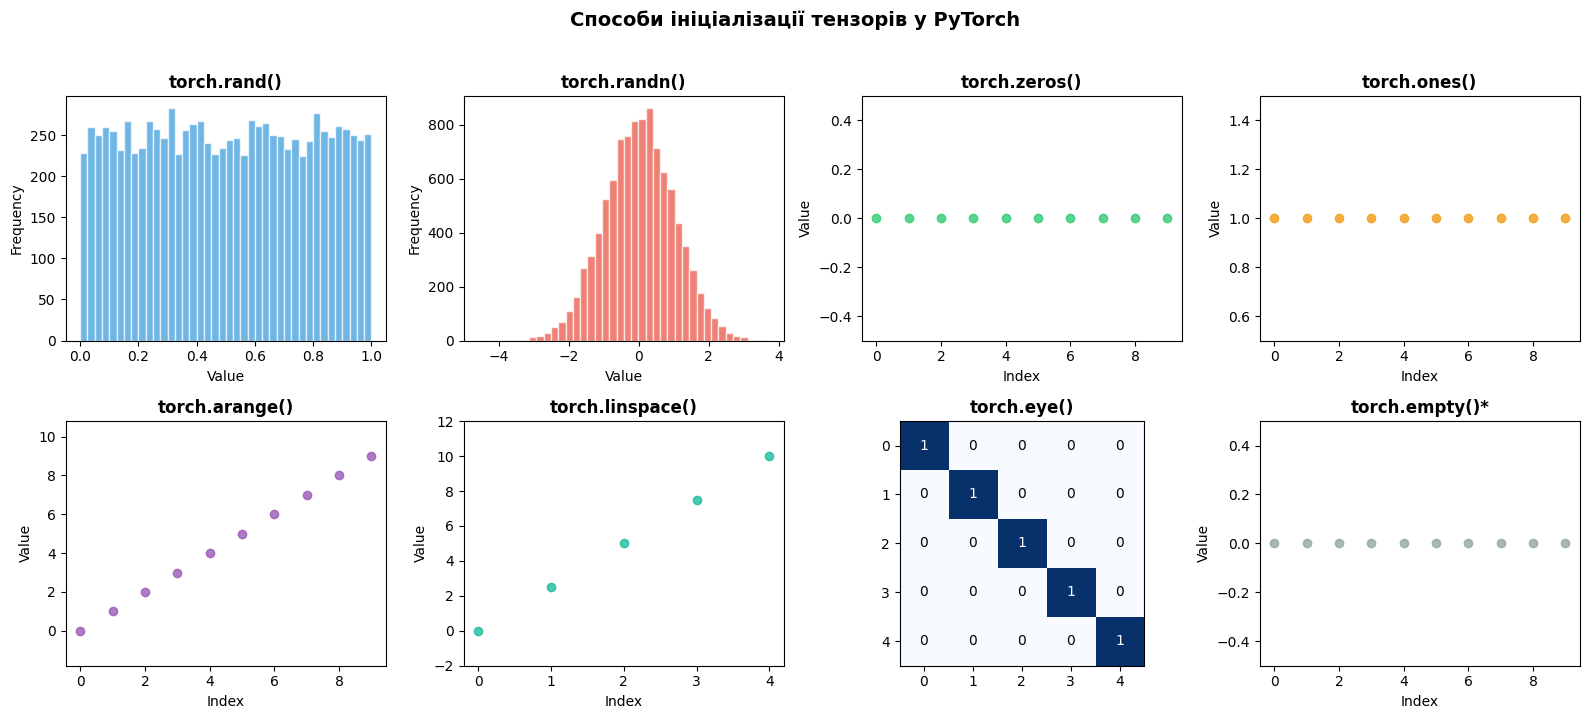

In [18]:
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

tensors_info = [
    (torch.rand(10000),              "torch.rand()",    "hist",    "#3498db"),
    (torch.randn(10000),             "torch.randn()",   "hist",    "#e74c3c"),
    (torch.zeros(10),                "torch.zeros()",   "scatter", "#2ecc71"),
    (torch.ones(10),                 "torch.ones()",    "scatter", "#f39c12"),
    (torch.arange(0, 10),            "torch.arange()",  "scatter", "#9b59b6"),
    (torch.linspace(0, 10, steps=5), "torch.linspace()","scatter", "#1abc9c"),
    (torch.eye(5),                   "torch.eye()",     "matrix",  "#e67e22"),
    (torch.zeros(10),                "torch.empty()*",  "scatter", "#95a5a6"),
]

for ax, (tensor, title, plot_type, color) in zip(axes.flat, tensors_info):
    np_data = tensor.numpy()
    ax.set_title(title, fontsize=12, fontweight="bold")

    if plot_type == "hist":
        ax.hist(np_data, bins=40, color=color, alpha=0.7, edgecolor="white")
        ax.set_ylabel("Frequency")
        ax.set_xlabel("Value")
    elif plot_type == "matrix":
        im = ax.imshow(np_data, cmap="Blues", vmin=0, vmax=1)
        for i in range(np_data.shape[0]):
            for j in range(np_data.shape[1]):
                ax.text(j, i, f"{np_data[i,j]:.0f}", ha="center", va="center",
                        color="white" if np_data[i,j] > 0.5 else "black", fontsize=10)
        ax.set_xticks(range(np_data.shape[1]))
        ax.set_yticks(range(np_data.shape[0]))
    else:
        ax.scatter(range(len(np_data)), np_data, color=color, alpha=0.8)
        ax.set_xlabel("Index")
        ax.set_ylabel("Value")
        y_min, y_max = np_data.min(), np_data.max()
        margin = max(0.5, (y_max - y_min) * 0.2)
        ax.set_ylim(y_min - margin, y_max + margin)

plt.suptitle("Способи ініціалізації тензорів у PyTorch", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. Перетворення "сирих" даних у тензори


In [19]:
houses = torch.tensor([
    # bedrooms, size_m2, age_years, price_k
    [2,  65,  15, 285],
    [3,  95,   8, 425],
    [4, 120,  25, 380],
    [3,  88,  42, 295],
    [5, 180,   3, 675],
    [2,  58,  50, 245]
], dtype=torch.float32)

print("Shape:", houses.shape)   # [6, 4] — 6 houses, 4 features each
print("Data type:", houses.dtype)
print()
print("Houses tensor:")
print(houses)
print()
print("Average price:", f"{houses[:, 3].mean():.0f}k")
print("Largest house:", f"{houses[:, 1].max():.0f} m²")

Shape: torch.Size([6, 4])
Data type: torch.float32

Houses tensor:
tensor([[  2.,  65.,  15., 285.],
        [  3.,  95.,   8., 425.],
        [  4., 120.,  25., 380.],
        [  3.,  88.,  42., 295.],
        [  5., 180.,   3., 675.],
        [  2.,  58.,  50., 245.]])

Average price: 384k
Largest house: 180 m²


### 3D-моделі як тензори

Torus vertices tensor: shape = torch.Size([3200, 3]), dtype = torch.float32
First 5 vertices:
tensor([[4.0000, 0.0000, 0.0000],
        [3.9871, 0.0000, 0.1604],
        [3.9485, 0.0000, 0.3167],
        [3.8855, 0.0000, 0.4647],
        [3.7994, 0.0000, 0.6007]])


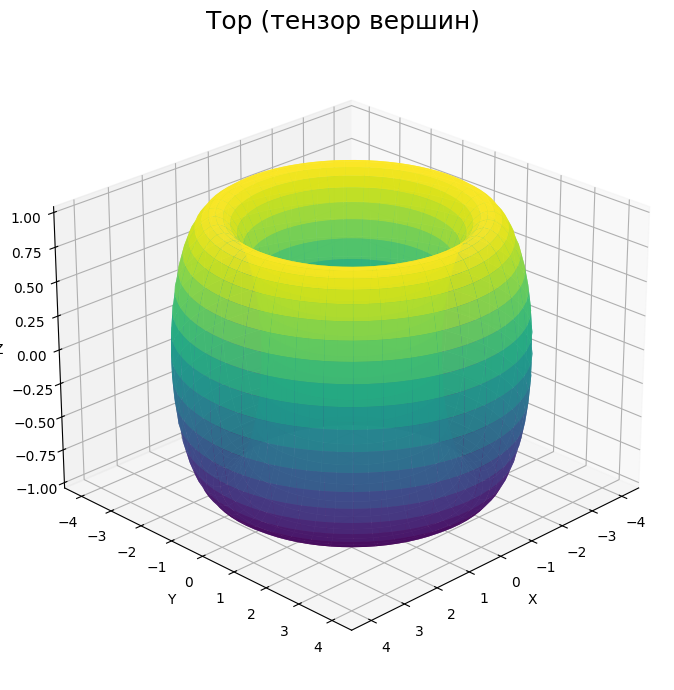

In [20]:
# === Parametric torus generation ===
def generate_torus(R=3.0, r=1.0, n_major=80, n_minor=40):
    """Generate torus vertices as a PyTorch tensor.
    R — major radius, r — minor radius."""
    theta = torch.linspace(0, 2 * torch.pi, n_major)
    phi   = torch.linspace(0, 2 * torch.pi, n_minor)

    theta_grid, phi_grid = torch.meshgrid(theta, phi, indexing="ij")

    x = (R + r * torch.cos(phi_grid)) * torch.cos(theta_grid)
    y = (R + r * torch.cos(phi_grid)) * torch.sin(theta_grid)
    z = r * torch.sin(phi_grid)

    vertices = torch.stack([x.flatten(), y.flatten(), z.flatten()], dim=1)
    return vertices, x, y, z

torus_vertices, torus_x, torus_y, torus_z = generate_torus()
print(f"Torus vertices tensor: shape = {torus_vertices.shape}, dtype = {torus_vertices.dtype}")
print(f"First 5 vertices:\n{torus_vertices[:5]}")

# === Matplotlib 3D visualization ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(
    torus_x.numpy(), torus_y.numpy(), torus_z.numpy(),
    cmap="viridis", alpha=0.9, edgecolor="none"
)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Тор (тензор вершин)", fontsize=18)
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()

### Завантаження 3D-моделі з інтернету

Формат `.obj` — це текстовий формат для 3D-моделей. Рядки, що починаються з `v`, містять координати вершин.:

Utah Teapot: 3644 vertices, tensor shape = torch.Size([3644, 3])
Bounding box: min = [-3.0, 0.0, -2.0]
              max = [3.434000015258789, 3.1500000953674316, 2.0]


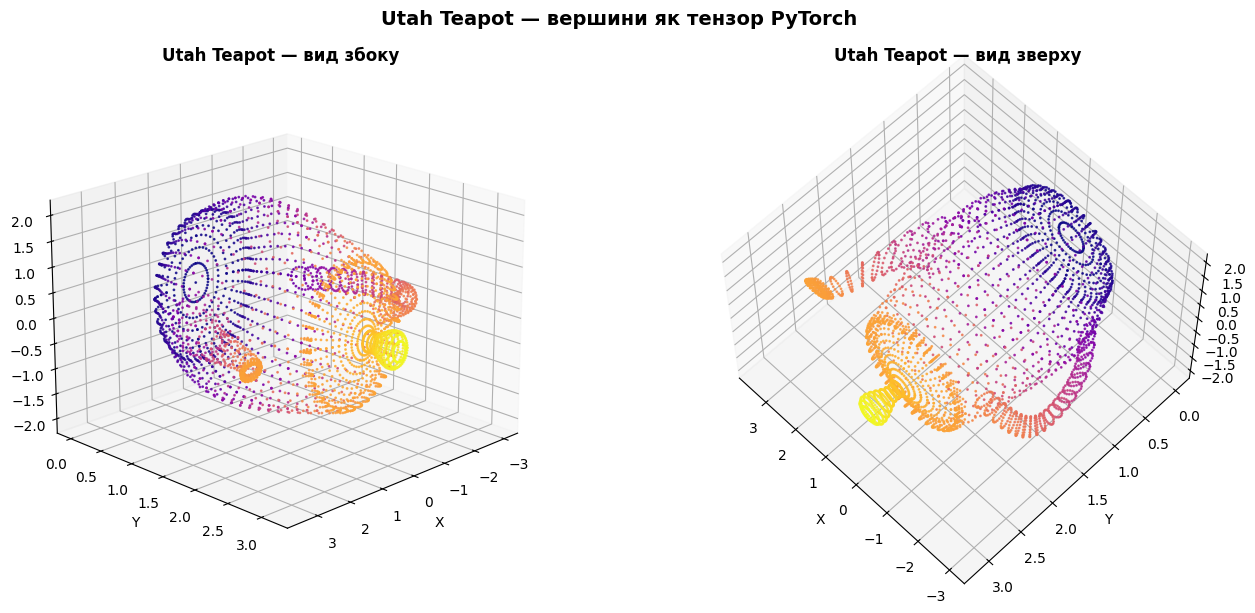

In [21]:
import urllib.request

OBJ_URL = "https://raw.githubusercontent.com/jaz303/utah-teapot/master/teapot.obj"

def parse_obj_vertices(text: str) -> torch.Tensor:
    """Parse .obj file content and return vertex coordinates as a tensor [N, 3]."""
    vertices = []
    for line in text.strip().split("\n"):
        parts = line.strip().split()
        if len(parts) >= 4 and parts[0] == "v":
            vertices.append([float(parts[1]), float(parts[2]), float(parts[3])])
    return torch.tensor(vertices, dtype=torch.float32)

# Download the .obj file
print(f"Downloading from {OBJ_URL} ...")
try:
    response = urllib.request.urlopen(OBJ_URL, timeout=15)
    obj_text = response.read().decode("utf-8")
    teapot_vertices = parse_obj_vertices(obj_text)
    print(f"Utah Teapot: {teapot_vertices.shape[0]} vertices, tensor shape = {teapot_vertices.shape}")
    print(f"Bounding box: min = {teapot_vertices.min(dim=0).values.tolist()}")
    print(f"              max = {teapot_vertices.max(dim=0).values.tolist()}")

    # Visualize from two angles
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "3d"})
    vx = teapot_vertices[:, 0].numpy()
    vy = teapot_vertices[:, 1].numpy()
    vz = teapot_vertices[:, 2].numpy()

    for ax, (elev, azim, title) in zip(axes, [
        (20, 45,  "Utah Teapot — вид збоку"),
        (60, 135, "Utah Teapot — вид зверху"),
    ]):
        ax.scatter(vx, vy, vz, c=vy, cmap="plasma", s=1, alpha=0.8)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.view_init(elev=elev, azim=azim)

    plt.suptitle("Utah Teapot — вершини як тензор PyTorch", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Не вдалося завантажити модель: {e}")
    print("Переконайтеся, що є з'єднання з інтернетом.")

## 4. Математичні операції з тензорами

PyTorch підтримує стандартні арифметичні операції, які виконуються **поелементно** (element-wise):

array([-3.      , -2.9916  , -2.9916  , ...,  3.428125,  3.428125,
        3.434   ], shape=(3644,), dtype=float32)

In [27]:
import torch

x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

# BASIC ARITHMETIC
print("x + y =", x + y)                # Addition
print("x * y =", x * y)               # Element-wise multiplication
print("x · y =", x @ y)                # Dot product

# AGGREGATIONS
print()
print("sum  =", x.sum())               # Sum all elements
print("mean =", x.mean())              # Average
print("max  =", x.max())               # Maximum value
print("min  =", x.min())               # Standard deviation

x + y = tensor([5., 7., 9.])
x * y = tensor([ 4., 10., 18.])
x · y = tensor(32.)

sum  = tensor(6.)
mean = tensor(2.)
max  = tensor(3.)
min  = tensor(1.)


## 5. Функції активації

Функції активації додають **нелінійність** до нейронної мережі. Без них мережа могла б обчислювати лише лінійні перетворення.

Основні функції активації:
- **ReLU** (Rectified Linear Unit) — найпопулярніша: обнуляє від'ємні значення
- **Sigmoid** — стискає значення до діапазону (0, 1)
- **Tanh** — стискає значення до діапазону (-1, 1)

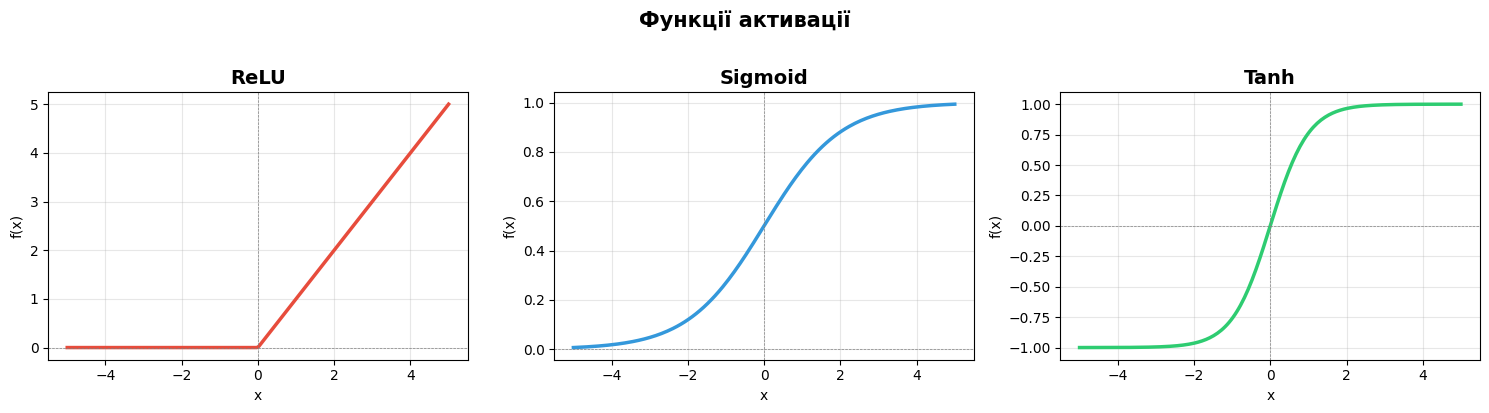

Input:   [-2.0, -1.0, 0.0, 1.0, 2.0]
ReLU:    [0.0, 0.0, 0.0, 1.0, 2.0]
Sigmoid: [0.12, 0.27, 0.5, 0.73, 0.88]
Tanh:    [-0.96, -0.76, 0.0, 0.76, 0.96]


In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

x = torch.linspace(-5, 5, 200)

relu_y    = F.relu(x)
sigmoid_y = torch.sigmoid(x)
tanh_y    = torch.tanh(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, y_vals, name, color in [
    (axes[0], relu_y,    "ReLU",    "#e74c3c"),
    (axes[1], sigmoid_y, "Sigmoid", "#3498db"),
    (axes[2], tanh_y,    "Tanh",    "#2ecc71"),
]:
    ax.plot(x.numpy(), y_vals.numpy(), color=color, linewidth=2.5)
    ax.axhline(y=0, color="grey", linewidth=0.5, linestyle="--")
    ax.axvline(x=0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True, alpha=0.3)

plt.suptitle("Функції активації", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Numeric demonstration
x_demo = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print("Input:  ", x_demo.tolist())
print("ReLU:   ", F.relu(x_demo).tolist())
print("Sigmoid:", [round(v, 2) for v in torch.sigmoid(x_demo).tolist()])
print("Tanh:   ", [round(v, 2) for v in torch.tanh(x_demo).tolist()])

## 6. Autograd — автоматичне диференціювання

Autograd

### Похідна — наскільки крута функція в одному напрямку?

Похідна $f'(x)$ показує, як швидко змінюється функція при малій зміні $x$. Наприклад, для $f(x) = x^2$:

$$f'(x) = 2x$$

В точці $x = 2$: $f'(2) = 4$ — це нахил дотичної.

### Градієнт — нахил у всіх напрямках одночасно

Для функції кількох змінних **градієнт** — це вектор часткових похідних:

$$\nabla f(x, y) = \left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}\right)$$

### Градієнтний спуск — рух вниз по схилу

Алгоритм навчання: ми обчислюємо градієнт функції втрат (loss) і рухаємо ваги моделі в протилежному напрямку, щоб зменшити помилку.

$$w_{\text{new}} = w_{\text{old}} - \eta \cdot \nabla L(w)$$

де $\eta$ — швидкість навчання (learning rate).

### Autograd на практиці — простий приклад

Для $f(x) = x^2$ при $x = 2$, очікуємо $f'(2) = 2 \cdot 2 = 4$:

In [38]:
x = torch.tensor(2.0, requires_grad=True)
print(x.shape)
# Define function f(x) = x²
f = x ** 2

# Calculate gradient
f.backward()

# Check the gradient (derivative) at our point x
print(f"f(x) = x²")
print(f"x = {x.item()}")
print(f"f(x) = {f.item()}")
print(f"f'(x) = {x.grad.item()}")  # Should be 4.0

torch.Size([])
f(x) = x²
x = 2.0
f(x) = 4.0
f'(x) = 4.0


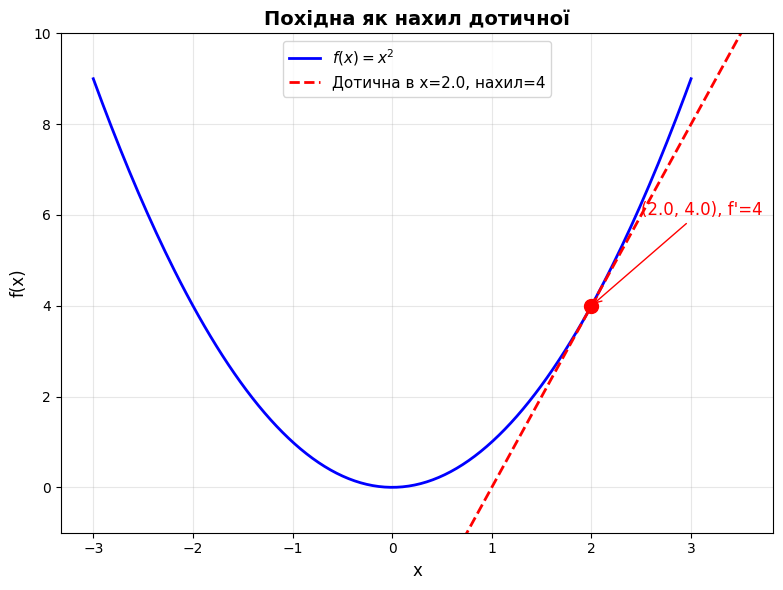

In [33]:
# Visualization of the derivative as a tangent line
import matplotlib.pyplot as plt
import numpy as np

x_vals = np.linspace(-3, 3, 200)
y_vals = x_vals ** 2

# Point where we compute the derivative
x0 = 2.0
y0 = x0 ** 2
slope = 2 * x0  # f'(x) = 2x

# Tangent line: y - y0 = slope * (x - x0)
tangent_x = np.linspace(0.5, 3.5, 100)
tangent_y = slope * (tangent_x - x0) + y0

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_vals, y_vals, "b-", linewidth=2, label="$f(x) = x^2$")
ax.plot(tangent_x, tangent_y, "r--", linewidth=2, label=f"Дотична в x={x0}, нахил={slope:.0f}")
ax.plot(x0, y0, "ro", markersize=10, zorder=5)
ax.annotate(f"({x0}, {y0}), f'={slope:.0f}",
            xy=(x0, y0), xytext=(x0 + 0.5, y0 + 2),
            fontsize=12, arrowprops=dict(arrowstyle="->", color="red"),
            color="red")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("f(x)", fontsize=12)
ax.set_title("Похідна як нахил дотичної", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 10)
plt.tight_layout()
plt.show()

### Складніший приклад

Для $f(x, y, z) = \sin(x) \cdot y^2 + e^z$:

In [44]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
z = torch.tensor(0.5, requires_grad=True)

# f(x,y,z) = sin(x) * y² + e^z
f = torch.sin(x) * y**2 + torch.exp(z)

# Calculate all partial derivatives at once
f.backward()

print(f"f(x,y,z) = sin(x) * y² + e^z")
print(f"At x=1, y=2, z=0.5:")
print(f"  ∂f/∂x = cos(x)*y² = cos(1)*4 ≈ {x.grad.item():.4f}")
print(f"  ∂f/∂y = sin(x)*2y  = sin(1)*4 ≈ {y.grad.item():.4f}")
print(f"  ∂f/∂z = e^z        = e^0.5   ≈ {z.grad.item():.4f}")

f(x,y,z) = sin(x) * y² + e^z
At x=1, y=2, z=0.5:
  ∂f/∂x = cos(x)*y² = cos(1)*4 ≈ 2.1612
  ∂f/∂y = sin(x)*2y  = sin(1)*4 ≈ 3.3659
  ∂f/∂z = e^z        = e^0.5   ≈ 1.6487


### Інтерактивна візуалізація градієнтного спуску

Розглянемо функцію $f(x, y) = x^2 + y^2$ — це парабола в 3D-просторі. Градієнт завжди вказує від мінімуму, тому для мінімізації ми рухаємось у протилежному напрямку:

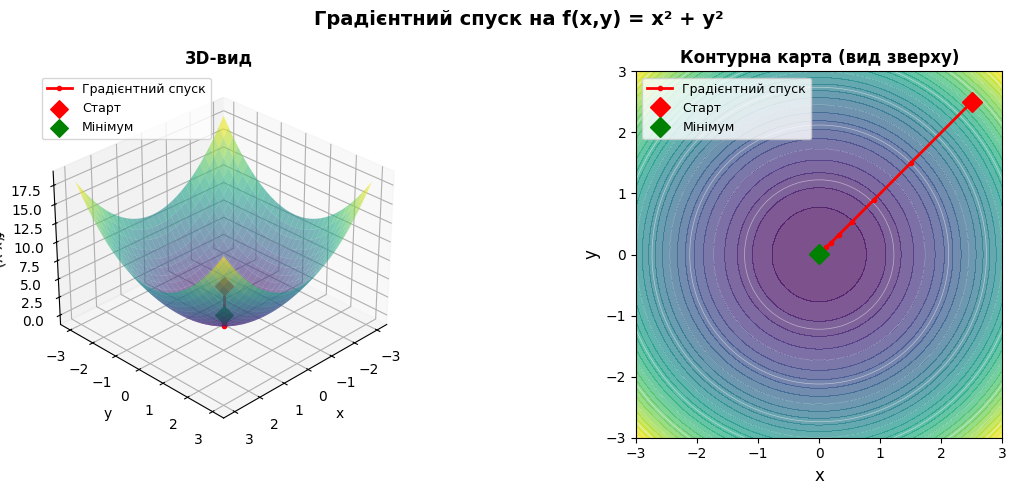

In [45]:
import numpy as np

# Create the surface f(x,y) = x² + y²
x_range = np.linspace(-3, 3, 60)
y_range = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

# Simulate gradient descent from (2.5, 2.5)
lr = 0.2
gd_x, gd_y, gd_z = [2.5], [2.5], [2.5**2 + 2.5**2]
for _ in range(15):
    grad_x = 2 * gd_x[-1]
    grad_y = 2 * gd_y[-1]
    new_x = gd_x[-1] - lr * grad_x
    new_y = gd_y[-1] - lr * grad_y
    gd_x.append(new_x)
    gd_y.append(new_y)
    gd_z.append(new_x**2 + new_y**2)

fig = plt.figure(figsize=(12, 5))

# 3D surface with gradient descent path
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.6, edgecolor="none")
ax1.plot(gd_x, gd_y, gd_z, "r.-", markersize=6, linewidth=2, label="Градієнтний спуск")
ax1.scatter([gd_x[0]], [gd_y[0]], [gd_z[0]], color="red", s=80, zorder=5, marker="D", label="Старт")
ax1.scatter([gd_x[-1]], [gd_y[-1]], [gd_z[-1]], color="green", s=80, zorder=5, marker="D", label="Мінімум")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("f(x,y)")
ax1.set_title("3D-вид", fontsize=12, fontweight="bold")
ax1.view_init(elev=30, azim=45)
ax1.legend(fontsize=9)

# 2D contour with gradient descent path (top-down view)
ax2 = fig.add_subplot(122)
ax2.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
ax2.contour(X, Y, Z, levels=15, colors="white", linewidths=0.5, alpha=0.5)
ax2.plot(gd_x, gd_y, "r.-", markersize=6, linewidth=2, label="Градієнтний спуск")
ax2.plot(gd_x[0], gd_y[0], "rD", markersize=10, label="Старт")
ax2.plot(gd_x[-1], gd_y[-1], "gD", markersize=10, label="Мінімум")
ax2.set_xlabel("x", fontsize=12)
ax2.set_ylabel("y", fontsize=12)
ax2.set_title("Контурна карта (вид зверху)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_aspect("equal")

plt.suptitle("Градієнтний спуск на f(x,y) = x² + y²", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Побудова нейронної мережі

Тепер об'єднаємо все вивчене для створення повноцінної нейронної мережі, яка прогнозує **ціну нерухомості** за ознаками.

Ми використаємо датасет **California Housing** зі sklearn — це набір даних про вартість нерухомості в Каліфорнії з 8 ознаками:

| Ознака | Опис |
|--------|------|
| MedInc | Медіанний дохід домогосподарства |
| HouseAge | Вік будинку (роки) |
| AveRooms | Середня кількість кімнат |
| AveBedrms | Середня кількість спалень |
| Population | Населення в районі |
| AveOccup | Середня заповненість |
| Latitude | Широта |
| Longitude | Довгота |

**Цільова змінна:** медіанна вартість будинку (у $100,000).

### Імпорт бібліотек

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

### Підготовка даних

In [47]:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
data_raw = housing.frame

print(f"Dataset shape: {data_raw.shape}")
print(f"Features: {list(housing.feature_names)}")
print(f"Target: MedHouseVal (median house value in $100k)")
print()
data_raw.head()

/Users/bausk/projects/lpnu/ml-practice/.conda/lib/python3.12/site-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


URLError: <urlopen error [Errno 8] nodename nor servname provided, or not known>

In [ ]:
# SEPARATE FEATURES FROM THE TARGET
x = data_raw.drop("MedHouseVal", axis=1)
y = data_raw["MedHouseVal"]

print(f"Features shape: {x.shape}")
print(f"Target shape:   {y.shape}")
print(f"Target range:   ${y.min()*100:.0f}k — ${y.max()*100:.0f}k")
print(f"Target mean:    ${y.mean()*100:.0f}k")

# DATA SPLIT 80/20
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    x.values, y.values, test_size=0.2, random_state=15
)

print(f"\nTrain: {X_train_raw.shape[0]} samples")
print(f"Test:  {X_test_raw.shape[0]} samples")

# NORMALISE
scaler_X = StandardScaler().fit(X_train_raw)
scaler_Y = StandardScaler().fit(Y_train_raw.reshape(-1, 1))

# Save for de-normalisation later
price_mean = scaler_Y.mean_[0]
price_std  = scaler_Y.scale_[0]

# CONVERT TO TENSORS
X_train = torch.FloatTensor(scaler_X.transform(X_train_raw))
X_test  = torch.FloatTensor(scaler_X.transform(X_test_raw))
Y_train = torch.FloatTensor(scaler_Y.transform(Y_train_raw.reshape(-1, 1)))
Y_test  = torch.FloatTensor(scaler_Y.transform(Y_test_raw.reshape(-1, 1)))

print(f"\nX_train tensor: {X_train.shape}")
print(f"Y_train tensor: {Y_train.shape}")

Features shape: (20640, 8)
Target shape:   (20640,)
Target range:   $15k — $500k
Target mean:    $207k

Train: 16512 samples
Test:  4128 samples

X_train tensor: torch.Size([16512, 8])
Y_train tensor: torch.Size([16512, 1])


### Визначення моделі

Архітектура нейронної мережі:
- **Вхідний шар:** 8 ознак (features)
- **Прихований шар 1:** 64 нейрони + ReLU
- **Прихований шар 2:** 32 нейрони + ReLU
- **Вихідний шар:** 1 нейрон (прогнозована ціна)

In [39]:
class HousePriceModel(nn.Module):
    def __init__(self, in_features=8, h1=64, h2=32, output_features=1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, output_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

model = HousePriceModel()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

HousePriceModel(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 2,689


### Цикл навчання

Процес навчання:
1. **Forward pass** — пропускаємо дані через мережу
2. **Loss** — обчислюємо помилку (MSE)
3. **Backward pass** — обчислюємо градієнти через autograd
4. **Update** — оновлюємо ваги за допомогою оптимізатора

In [40]:
epochs = 200
learning_rate = 0.01
torch.manual_seed(15)

losses = []

optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_func = nn.MSELoss()

for i in range(epochs):
    # Forward pass
    y_pred = model.forward(X_train)

    # Measure the loss
    loss = loss_func(y_pred, Y_train)

    # Save loss for visualization
    losses.append(loss.detach().numpy().item())

    # Print loss periodically
    if i % 50 == 0:
        print(f"Epoch {i:>4d} | Loss: {loss.item():.6f}")

    # Clear gradients from previous step
    optimiser.zero_grad()
    # Backpropagation
    loss.backward()
    # Update weights
    optimiser.step()

print(f"Epoch {epochs:>4d} | Loss: {losses[-1]:.6f}")
print("\nTraining complete!")

Epoch    0 | Loss: 0.989057
Epoch   50 | Loss: 0.279777
Epoch  100 | Loss: 0.224874
Epoch  150 | Loss: 0.207073
Epoch  200 | Loss: 0.197134

Training complete!


### Візуалізація функції втрат

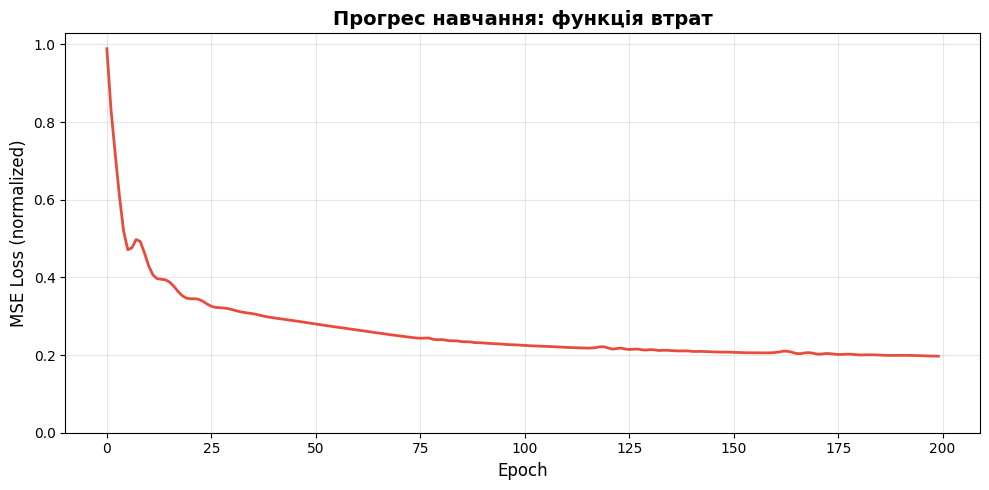

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2, color="#e74c3c")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss (normalized)", fontsize=12)
plt.title("Прогрес навчання: функція втрат", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Тестування моделі на невідомих даних

In [42]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)

    # DENORMALIZE BACK TO REAL PRICES (in $100k units)
    predictions_real = predictions * price_std + price_mean
    Y_test_real = Y_test * price_std + price_mean

    print("TEST PREDICTIONS (UNSEEN DATA):")
    mae = mean_absolute_error(Y_test_real.numpy(), predictions_real.numpy())
    mape = mean_absolute_percentage_error(Y_test_real.numpy(), predictions_real.numpy()) * 100

    # Calculate percentage errors
    pct_errors = torch.abs((Y_test_real - predictions_real) / Y_test_real) * 100

    within_10 = (pct_errors <= 10).sum().item()
    within_20 = (pct_errors <= 20).sum().item()
    total = len(Y_test_real)

print(f"\nOverall performance:")
print(f"  MAE:  ${mae * 100:,.0f}k")
print(f"  MAPE: {mape:.1f}%")
print(f"  Within 10%: {within_10}/{total} ({within_10/total*100:.0f}%)")
print(f"  Within 20%: {within_20}/{total} ({within_20/total*100:.0f}%)")

TEST PREDICTIONS (UNSEEN DATA):

Overall performance:
  MAE:  $37k
  MAPE: 20.7%
  Within 10%: 1493/4128 (36%)
  Within 20%: 2599/4128 (63%)


### Візуалізація прогнозів

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: predicted vs actual
ax = axes[0]
pred_np = predictions_real.numpy().flatten()
actual_np = Y_test_real.numpy().flatten()
ax.scatter(actual_np, pred_np, alpha=0.3, s=10, color="#3498db")
lims = [min(actual_np.min(), pred_np.min()), max(actual_np.max(), pred_np.max())]
ax.plot(lims, lims, "r--", linewidth=2, label="Ідеальний прогноз")
ax.set_xlabel("Фактична ціна ($100k)", fontsize=12)
ax.set_ylabel("Прогнозована ціна ($100k)", fontsize=12)
ax.set_title("Прогноз vs Факт", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# Error distribution
ax = axes[1]
errors = pred_np - actual_np
ax.hist(errors, bins=50, color="#2ecc71", alpha=0.7, edgecolor="white")
ax.axvline(x=0, color="red", linewidth=2, linestyle="--")
ax.set_xlabel("Помилка прогнозу ($100k)", fontsize=12)
ax.set_ylabel("Кількість", fontsize=12)
ax.set_title("Розподіл помилок", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Висновки

У цьому зошиті ми пройшли повний шлях від основ PyTorch до побудови нейронної мережі:

1. **Тензори** — базова структура даних PyTorch для представлення чисел, зображень, 3D-моделей
2. **Математичні операції** — поелементні операції, агрегації, функції активації
3. **Autograd** — автоматичне обчислення градієнтів для навчання моделей
4. **Нейронна мережа** — повний пайплайн: дані → модель → навчання → тестування

### Важливі висновки:
- **Якість ознак** важливіша за складність моделі
- Для табличних даних на практиці часто краще працюють **XGBoost** або **LightGBM**
- Нейронні мережі найкраще працюють з **зображеннями**, **текстом** та **послідовностями**
- Завжди нормалізуйте дані перед подачею в нейронну мережу

### Подальше вивчення:
- [PyTorch Documentation](https://pytorch.org/docs/stable/)
- [PyTorch Tutorials](https://pytorch.org/tutorials/)
- Convolutional Neural Networks (CNN) для зображень
- Recurrent Neural Networks (RNN) / Transformers для тексту